## Задача 3. Сравнение методов классификации

### Васаулюа Брюнотт Тази  М81

In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
custom_colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]
import warnings
from scipy.special import expit
from sklearn.base import BaseEstimator
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

Самостоятельно реализовать один из методов классификации, с возможностью настройки гиперпараметров.

 (**+2 балла**) Реализовать еще один из методов классификации и добавить его в сравнение.

- SVM

- Logistic Regression

In [162]:
class MyLogRegClassifier(BaseEstimator):
    def __init__(self, alpha=1e-1, lr=1e-2, num_iter=1000):
        self._alpha = alpha
        self._lr = lr
        self._num_iter = num_iter

    def fit(self, X_train, y_train):
        num_samples, num_features = X_train.shape

        self.weights = np.zeros(num_features, )
        self.bias = 0

        for iter in range(self._num_iter):
            preds = expit(np.dot(X_train, self.weights) + self.bias)
            errors = preds - y_train

            w_grad = (2 / num_samples) * np.dot(X_train.T, errors) + self._alpha * self.weights
            b_grad = (2 / num_samples) * np.sum(errors)

            self.weights -= self._lr * w_grad
            self.bias -= self._lr * b_grad

        return self

    def predict(self, X_test):
        pred_probs = expit(np.dot(X_test, self.weights) + self.bias)
        return np.where(pred_probs < 0.5, 0, 1)

    def get_params(self, deep=True):
        return {'alpha': self._alpha,
                'lr': self._lr,
                'num_iter': self._num_iter}

    def set_params(self, **parameters):
        for param, value in parameters.items():
            setattr(self, param, value)
        return self

In [163]:
class MySVMClassifier(BaseEstimator):
    def __init__(self, alpha=1e-1, Lambda=1e-1, num_iter=10):
        self._alpha = alpha
        self._lambda = Lambda
        self._num_iter = num_iter

    def fit(self, X_train, y_train):
        y_train_labels = np.where(y_train <= 0, -1, 1)
        self.weights = np.zeros(X_train.shape[1])
        self.bias = 0
        for iter in range(self._num_iter):
            for i, x_i in enumerate(X_train):
                dw = 0
                db = 0
                M = y_train_labels[i] * (np.dot(x_i, self.weights) - self.bias)
                if  M >= 1:
                    dw = 2 * self._lambda * self.weights
                    db = 0
                else:
                    dw = 2 * self._lambda * self.weights - np.dot(x_i, y_train_labels[i])
                    db = y_train_labels[i]

                self.weights -= self._alpha * dw
                self.bias -= self._alpha * db

        return self

    def predict(self, X_test):
        labels = np.sign(X_test @ self.weights - self.bias)
        preds = np.where(labels <= -1, 0, 1)
        return preds

    def get_params(self, deep=True):
        return {'alpha': self._alpha,
                'Lambda': self._lambda,
                'num_iter': self._num_iter}

    def set_params(self, **parameters):
        for param, value in parameters.items():
            setattr(self, param, value)
        return self

Взять данные для предсказания заболеваний сердца [тут](https://github.com/rustam-azimov/ml-course/tree/main/data/heart_disease) (целевой признак для предсказания --- **target**). Демо блокнот с анализом этих данных можно найти [тут](https://github.com/rustam-azimov/ml-course/blob/main/practice/practice07_knn_nb/practice07_part02_classification_heart_disease_demo.ipynb).

- Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (**Data Cleaning**).
- Выполнить разведочный анализ (**EDA**), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи классификации.
- При необходимости выполнить полезные преобразования данных (например, трансформировать категариальные признаки в количественные), убрать ненужные признаки, создать новые (**Feature Engineering**).

In [164]:
df = pd.read_csv(r"data\heart_disease\heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


Описание датасета:
- age - age in years
- sex - (1 = male; 0 = female)
- cp - chest pain type
- trestbps - resting blood pressure (in mm Hg on admission to the hospital)
- chol - serum cholestoral in mg/dl
- fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
- restecg - resting electrocardiographic results
- thalach - maximum heart rate achieved
- exang - exercise induced angina (1 = yes; 0 = no)
- oldpeak - ST depression induced by exercise relative to rest
- slope - the slope of the peak exercise ST segment
- ca - number of major vessels (0-3) colored by flourosopy
- thal - 3 = normal; 6 = fixed defect; 7 = reversable defect
- target - have disease or not (1=yes, 0=no)
#### Необходимо решить задачу классификации и научиться предсказывать целовой признак target (имеет ли пациент заболевание сердца).

In [165]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## EDA

<Axes: xlabel='target', ylabel='count'>

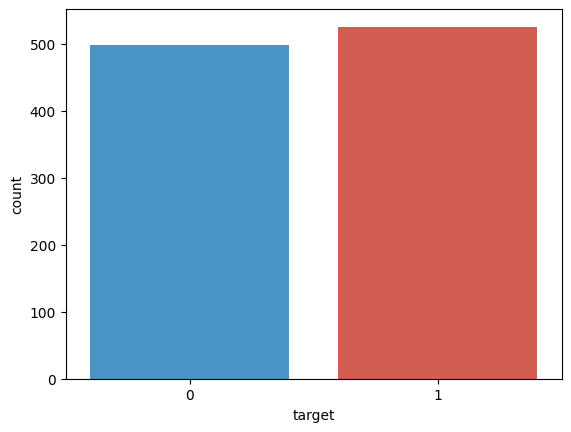

In [167]:
sns.countplot(x="target", data=df, palette=custom_colors)

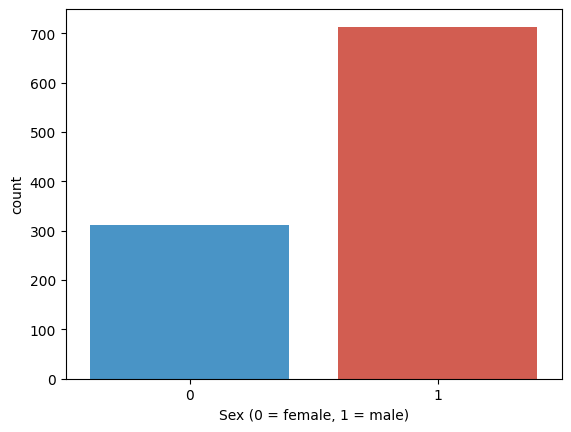

In [168]:
sns.countplot(x='sex', data=df, palette=custom_colors)
plt.xlabel("Sex (0 = female, 1 = male)")
plt.show()

Датасет содержит больше данных пациентов мужского пола.

In [169]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.569138,0.827655,0.482966,134.106212,251.292585,0.164329,0.456914,139.130261,0.549098,1.600200,1.166333,1.158317,2.539078
1,52.408745,0.570342,1.378327,129.245247,240.979087,0.134981,0.598859,158.585551,0.134981,0.569962,1.593156,0.370722,2.119772


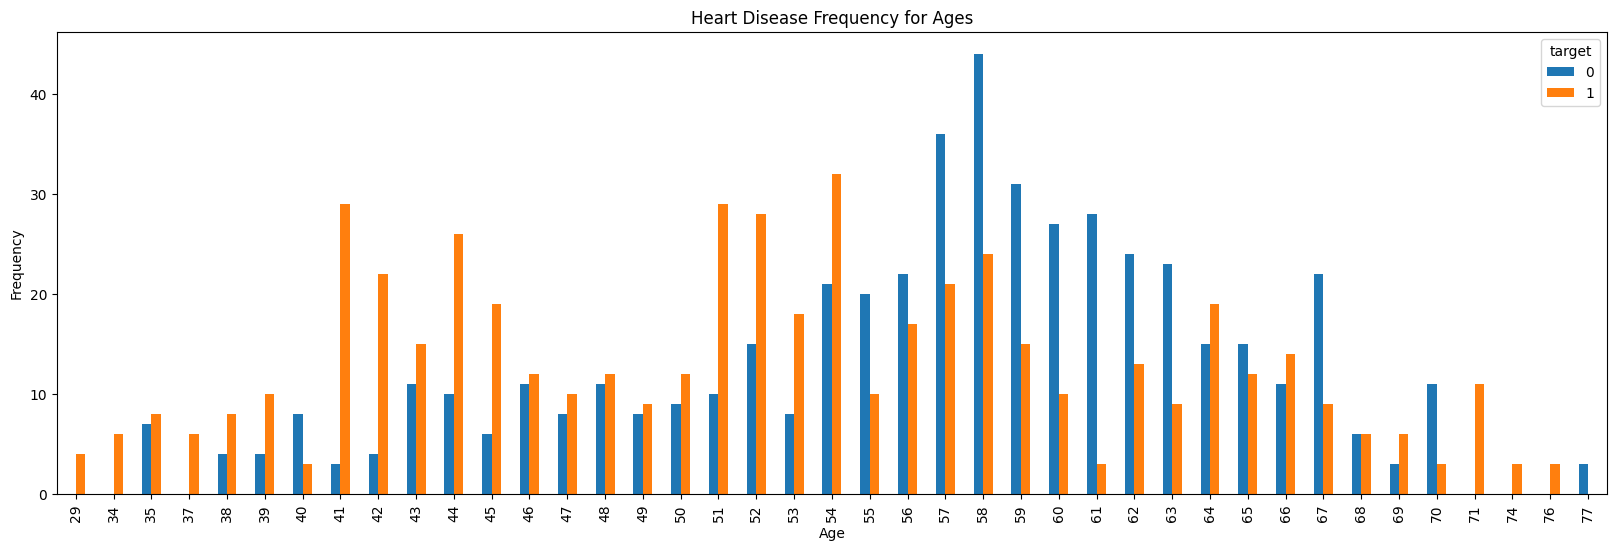

In [170]:
pd.crosstab(df.age,df.target).plot(kind="bar", figsize=(20, 6))
plt.title('Heart Disease Frequency for Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

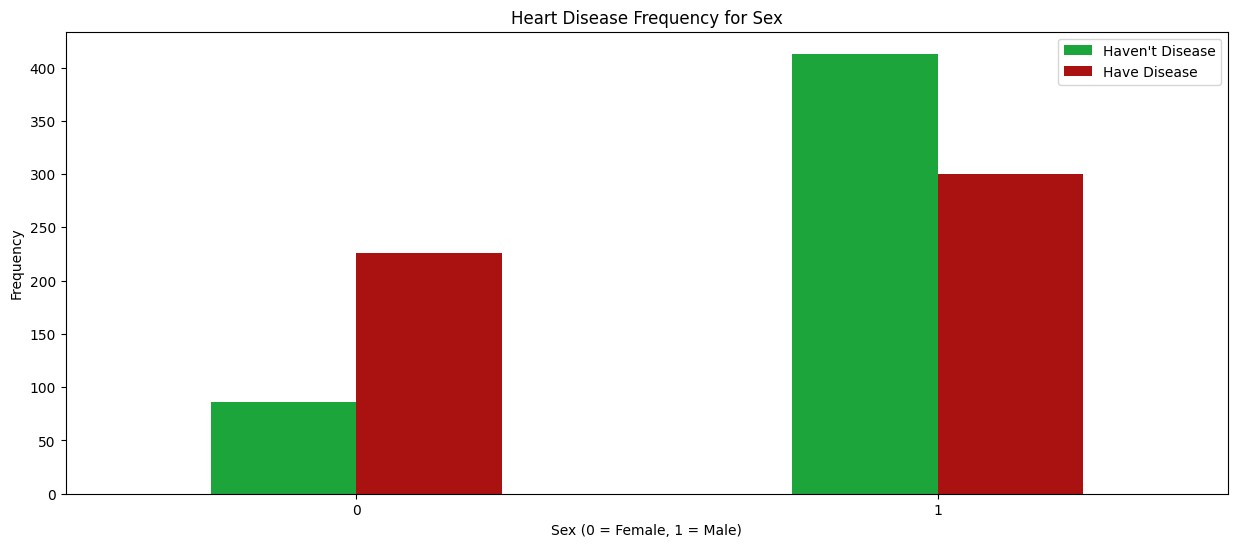

In [171]:
pd.crosstab(df.sex,df.target).plot(kind="bar", figsize=(15, 6), color=['#1CA53B', '#AA1111' ])
plt.title('Heart Disease Frequency for Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.xticks(rotation=0)
plt.legend(["Haven't Disease", "Have Disease"])
plt.ylabel('Frequency')
plt.show()

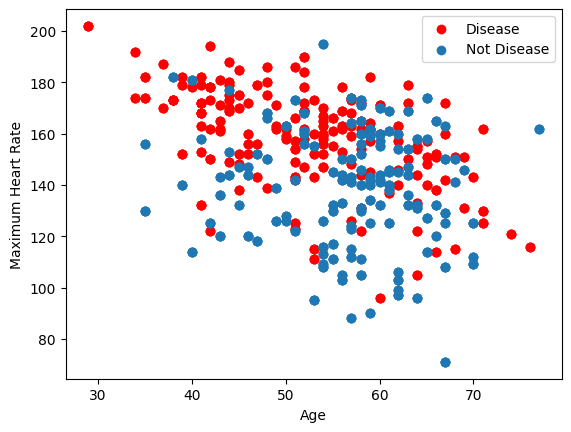

In [172]:
plt.scatter(x=df.age[df.target==1], y=df.thalach[(df.target==1)], c="red")
plt.scatter(x=df.age[df.target==0], y=df.thalach[(df.target==0)])
plt.legend(["Disease", "Not Disease"])
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.show()

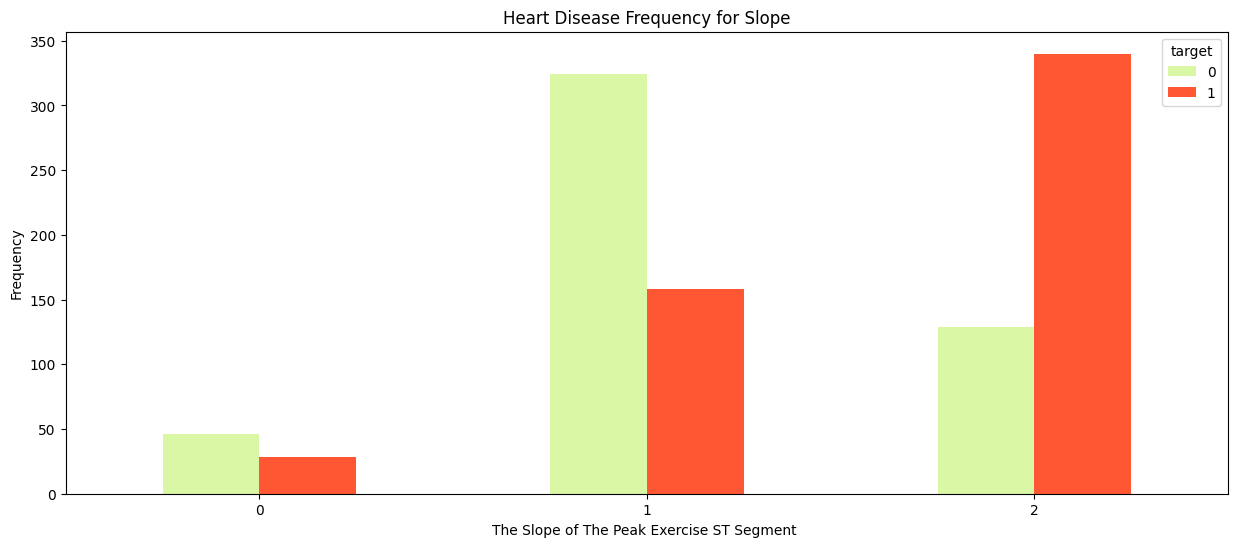

In [173]:
pd.crosstab(df.slope,df.target).plot(kind="bar", figsize=(15, 6), color=['#DAF7A6','#FF5733' ])
plt.title('Heart Disease Frequency for Slope')
plt.xlabel('The Slope of The Peak Exercise ST Segment ')
plt.xticks(rotation = 0)
plt.ylabel('Frequency')
plt.show()

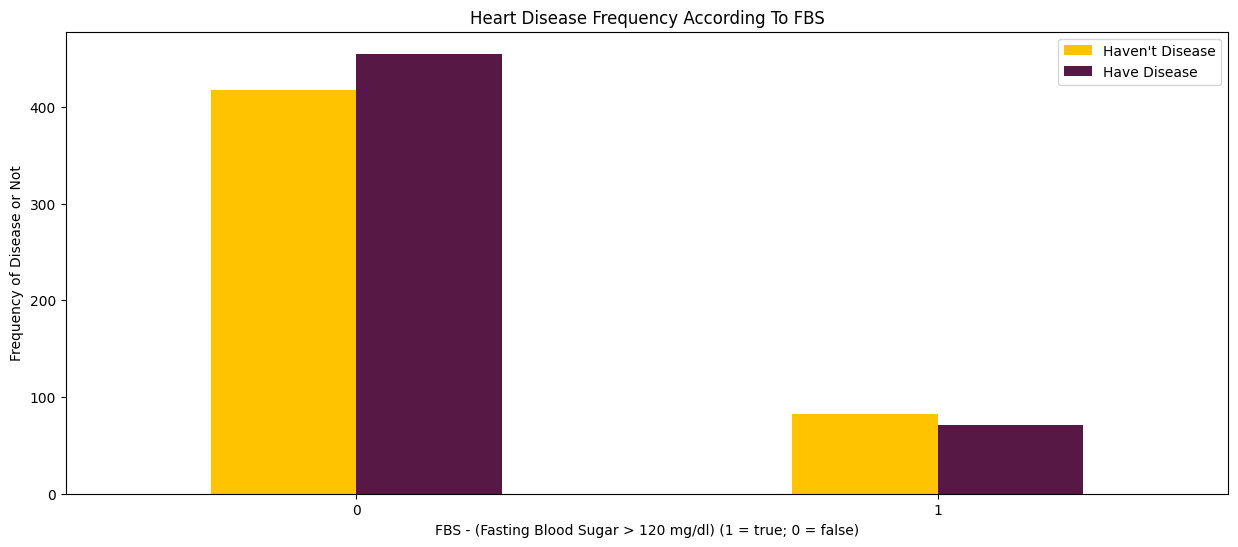

In [174]:
pd.crosstab(df.fbs,df.target).plot(kind="bar", figsize=(15, 6), color=['#FFC300','#581845' ])
plt.title('Heart Disease Frequency According To FBS')
plt.xlabel('FBS - (Fasting Blood Sugar > 120 mg/dl) (1 = true; 0 = false)')
plt.xticks(rotation = 0)
plt.legend(["Haven't Disease", "Have Disease"])
plt.ylabel('Frequency of Disease or Not')
plt.show()

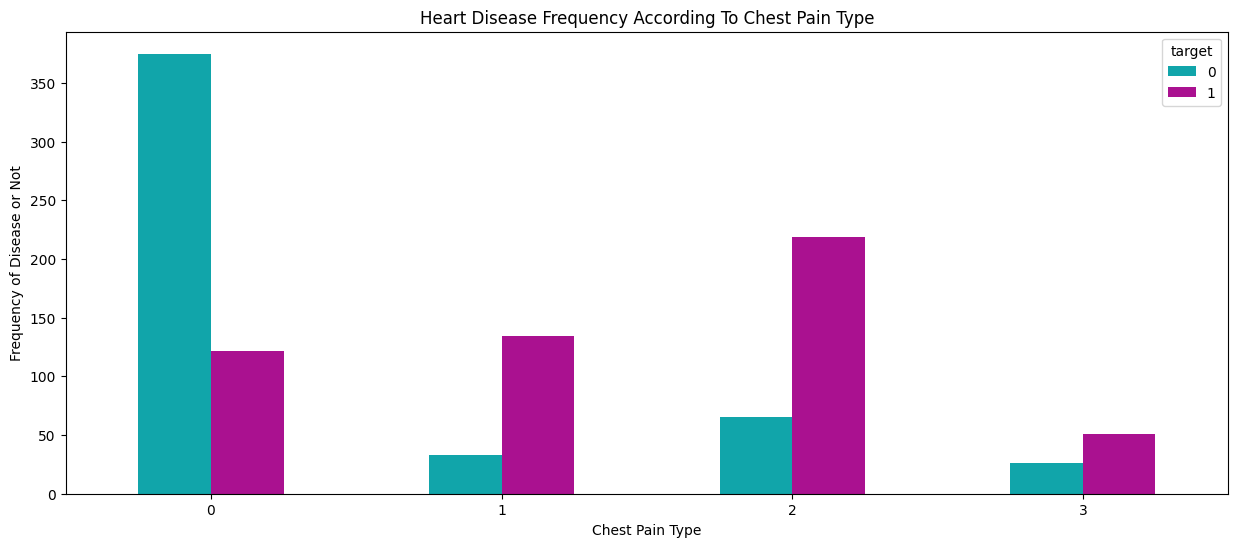

In [175]:
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(15, 6), color=['#11A5AA','#AA1190' ])
plt.title('Heart Disease Frequency According To Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.xticks(rotation = 0)
plt.ylabel('Frequency of Disease or Not')
plt.show()

### Преобразование категориальных признаков

In [176]:
cp_dum = pd.get_dummies(df['cp'], prefix = "cp")
thal_dum = pd.get_dummies(df['thal'], prefix = "thal")
slope_dum = pd.get_dummies(df['slope'], prefix = "slope")
frames = [df, cp_dum, thal_dum, slope_dum]
df = pd.concat(frames, axis = 1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,52,1,0,125,212,0,1,168,0,1.0,...,False,False,False,False,False,False,True,False,False,True
1,53,1,0,140,203,1,0,155,1,3.1,...,False,False,False,False,False,False,True,True,False,False
2,70,1,0,145,174,0,1,125,1,2.6,...,False,False,False,False,False,False,True,True,False,False
3,61,1,0,148,203,0,1,161,0,0.0,...,False,False,False,False,False,False,True,False,False,True
4,62,0,0,138,294,1,1,106,0,1.9,...,False,False,False,False,False,True,False,False,True,False


In [177]:
df = df.drop(columns = ['cp', 'thal', 'slope'])
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,...,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3,slope_0,slope_1,slope_2
0,52,1,125,212,0,1,168,0,1.0,2,...,False,False,False,False,False,False,True,False,False,True
1,53,1,140,203,1,0,155,1,3.1,0,...,False,False,False,False,False,False,True,True,False,False
2,70,1,145,174,0,1,125,1,2.6,0,...,False,False,False,False,False,False,True,True,False,False
3,61,1,148,203,0,1,161,0,0.0,1,...,False,False,False,False,False,False,True,False,False,True
4,62,0,138,294,1,1,106,0,1.9,3,...,False,False,False,False,False,True,False,False,True,False


Используя **подбор гиперпараметров**, **кросс-валидацию** и при необходимости **масштабирование данных**, добиться наилучшего качества предсказания от Вашей реализации на выделенной заранее тестовой выборке.

In [178]:
y = df['target']
X = df.drop(columns=['target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Повторить предыдущий пункт для библиотечных реализаций (например, из **sklearn**) всех пройденных методов классификации (**logistic regression, svm, knn, naive bayes, decision tree**).
Сравнить все обученные модели, построить их **confusion matrices**. Сделать выводы о полученных моделях в рамках решения задачи классификации на выбранных данных.

In [179]:
lr = LogisticRegression(random_state=42)

C_grid = [1e-3, 1e-2, 1e-1]
searcher = GridSearchCV(lr, {'C': C_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_lr = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'C': 0.01}
Best score:  0.8585365853658538


In [180]:
svc = SVC(random_state=42)

C_grid = [0.1, 0.25, 0.5, 0.75, 1, 2]
kernel_grid = ["linear", "rbf"]
gamma_grid = ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1, 1]

searcher = GridSearchCV(svc, {'C': C_grid, 'kernel': kernel_grid, 'gamma': gamma_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_svc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'C': 0.5, 'gamma': 1, 'kernel': 'rbf'}
Best score:  0.9658536585365853


In [181]:
my_svc = MySVMClassifier()  # собственная реализация

lambda_grid = np.linspace(1e-4, 1e-1, 5)
alpha_grid = np.linspace(1e-4, 1e-1, 5)

searcher = GridSearchCV(my_svc, {'Lambda': lambda_grid, 'alpha': alpha_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_my_svc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'Lambda': np.float64(0.0001), 'alpha': np.float64(0.0001)}
Best score:  0.8146341463414635


In [182]:
mlrc = MyLogRegClassifier()  # собственная реализация

lr_grid = [1e-3, 1e-2, 1e-1]
alpha_grid = [1e-3, 1e-2, 1e-1]

searcher = GridSearchCV(mlrc, {'lr': lr_grid, 'alpha': alpha_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_my_lrc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'alpha': 0.001, 'lr': 0.001}
Best score:  0.8560975609756097


In [ ]:
knc = KNeighborsClassifier()

n_neighbors_grid = np.arange(1, 20, 2)
weights_grid = ['distance', 'uniform']

searcher = GridSearchCV(knc, {'n_neighbors': n_neighbors_grid, 'weights': weights_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_knc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

In [ ]:
var_smoothing_grid = np.logspace(0, -10, 100)

gnb = GaussianNB()
searcher = GridSearchCV(gnb, {'var_smoothing': var_smoothing_grid}, scoring='accuracy', cv=5)

searcher = searcher.fit(X_train_scaled, y_train)
best_gnb = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'var_smoothing': np.float64(0.4977023564332111)}
Best score:  0.8426829268292684


In [ ]:
dtc = DecisionTreeClassifier(random_state=37)

criterion_grid = ["gini", "entropy", "log_loss"]
max_features_grid = [None, 0.5, 2, 5, 10]
min_samples_split_grid = [2, 3, 4, 5, 10]

searcher = GridSearchCV(dtc, {'criterion': criterion_grid, 'max_features': max_features_grid, 'min_samples_split': min_samples_split_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_dtc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

Best params:  {'criterion': 'gini', 'max_features': None, 'min_samples_split': 2}
Best score:  0.976829268292683


In [ ]:
y_my_lr = best_my_lrc.predict(X_test_scaled)
y_my_svc = best_my_svc.predict(X_test_scaled)

y_lr = best_lr.predict(X_test_scaled)
y_svc = best_svc.predict(X_test_scaled)
y_knc = best_knc.predict(X_test_scaled)
y_gnb = best_gnb.predict(X_test_scaled)
y_dtc = best_dtc.predict(X_test_scaled)

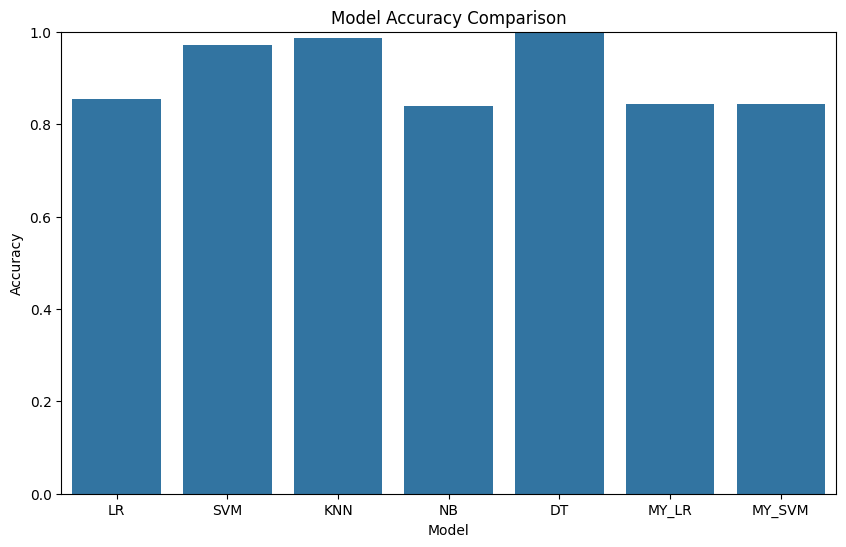

In [ ]:

scores = {
    'LR': accuracy_score(y_test, y_lr),
    'SVM': accuracy_score(y_test, y_svc),
    'KNN': accuracy_score(y_test, y_knc),
    'NB': accuracy_score(y_test, y_gnb),
    'DT': accuracy_score(y_test, y_dtc),
    'MY_LR': accuracy_score(y_test, y_my_lr),
    'MY_SVM': accuracy_score(y_test, y_my_svc)
}

# Create a DataFrame for better visualization
scores_df = pd.DataFrame(list(scores.items()), columns=['Model', 'Accuracy'])

# Plotting the scores using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=scores_df)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)  # Set y-axis limits to show accuracy percentage
plt.show()

In [ ]:
scores_df

,Model,Accuracy
0,LR,0.853659
1,SVM,0.970732
2,KNN,0.985366
3,NB,0.839024
4,DT,1.000000
5,MY_LR,0.843902
6,MY_SVM,0.843902


Confusion Matrix

In [ ]:

cm_lr = confusion_matrix(y_test, y_lr)
cm_knn = confusion_matrix(y_test, y_knc)
cm_svm = confusion_matrix(y_test, y_svc)
cm_nb = confusion_matrix(y_test, y_gnb)
cm_dtc = confusion_matrix(y_test, y_dtc)
cm_my_lr = confusion_matrix(y_test, y_my_lr)
cm_my_svc = confusion_matrix(y_test, y_my_svc)

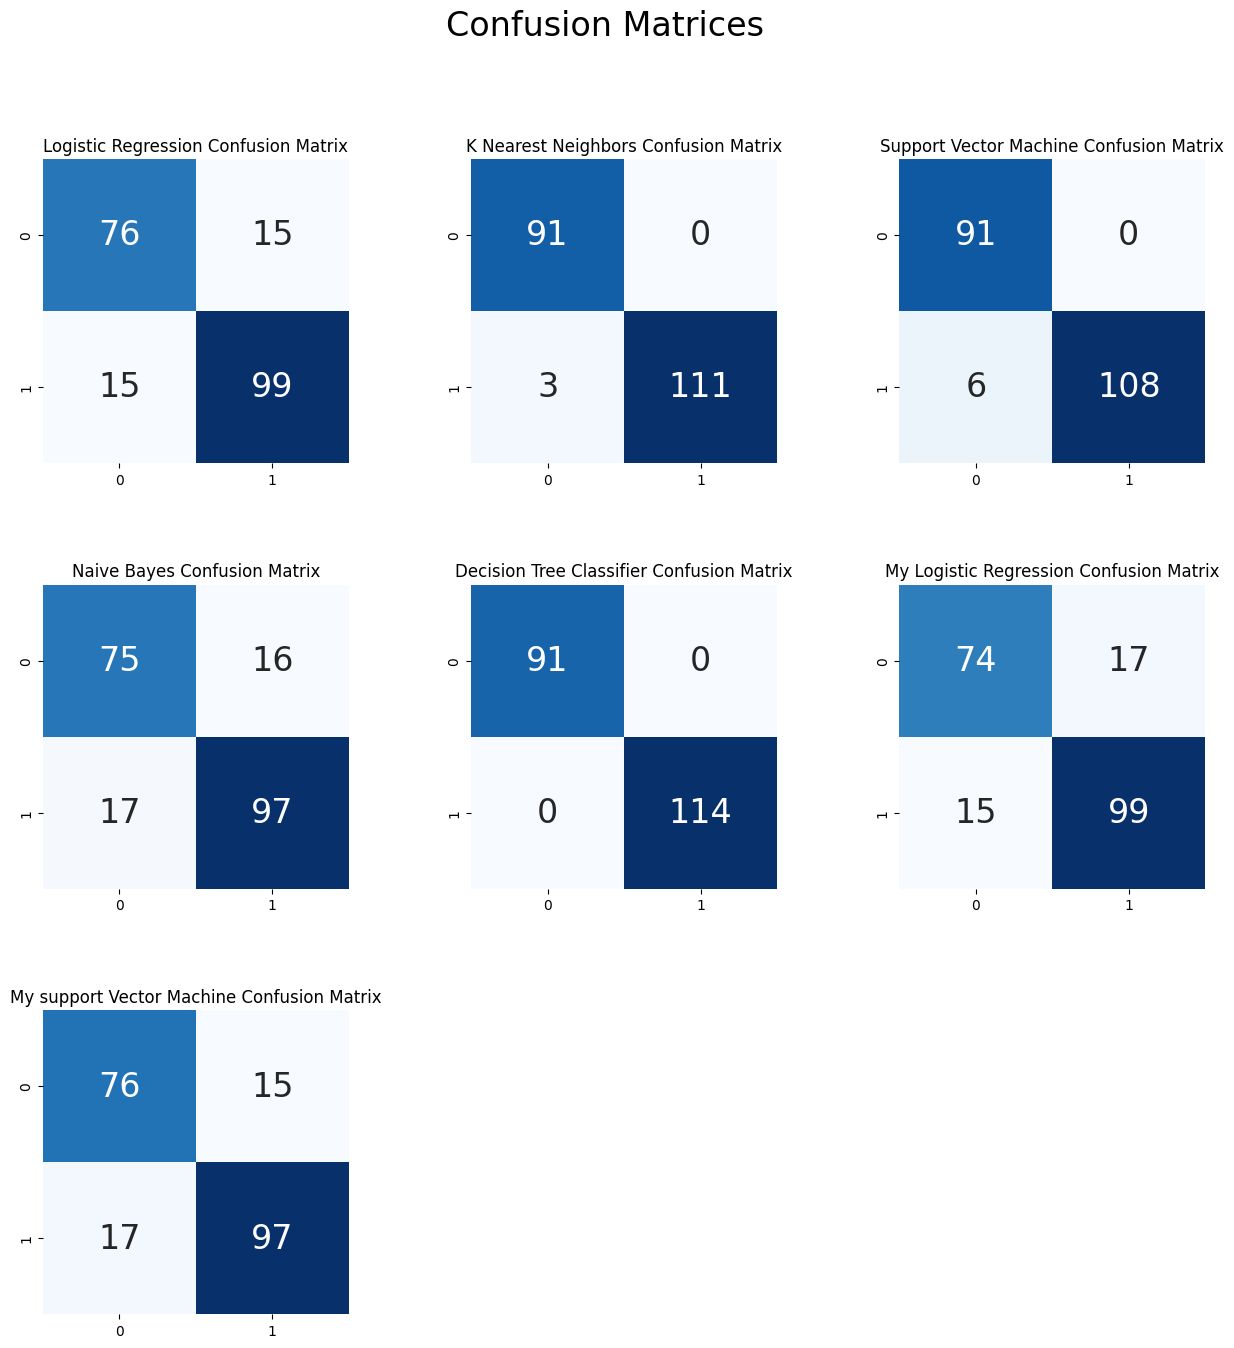

In [ ]:
plt.figure(figsize=(15, 15))

plt.suptitle("Confusion Matrices", fontsize=24)
plt.subplots_adjust(wspace = 0.4, hspace= 0.4)

plt.subplot(3,3,1)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,2)
plt.title("K Nearest Neighbors Confusion Matrix")
sns.heatmap(cm_knn,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,3)
plt.title("Support Vector Machine Confusion Matrix")
sns.heatmap(cm_svm,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,4)
plt.title("Naive Bayes Confusion Matrix")
sns.heatmap(cm_nb,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,5)
plt.title("Decision Tree Classifier Confusion Matrix")
sns.heatmap(cm_dtc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,6)
plt.title("My Logistic Regression Confusion Matrix")
sns.heatmap(cm_my_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,7)
plt.title("My support Vector Machine Confusion Matrix")
sns.heatmap(cm_my_svc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.show()

 (**+3 балла**) Найти данные, на которых интересно будет решать задачу классификации. Повторить все пункты задания на новых данных.

Используя набор данных, выбранный для задания 1:[Real Estate Saint Petersburg 2014 - 2019 (Недвижимость Санкт-Петербурга 2014 - 2019)](https://www.kaggle.com/datasets/litvinenko630/real-estate-saint-petersburg-2014-2019) из Kaggle, я хотела бы разрешить задание классификации, классифицируя объекты между дорогой и нормальной(приемлемой) ценой.
Данные уже чистие и готовые к использованию. Данные содержат информацию о продаже недвижимости в  Санкт-Петербурге с 2014 по 2019 год.

In [ ]:
cleaned_data = pd.read_csv(r"data\spb\cleaned_data.csv", encoding='utf-8')
cleaned_data.head()

,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,price_per_area
0,13000000.0,108.0,3,2.700000,16.0,51.000000,8,1,0,0,25.000000,1.150082,34,18863.0,16028.0,1.0,482.000000,2.0,755.0000,120370.370370
1,3350000.0,40.4,1,2.771499,11.0,18.600000,1,1,0,0,11.000000,2.000000,327,12817.0,18603.0,0.0,490.804555,0.0,517.9809,82920.792079
2,5196000.0,56.0,2,2.771499,5.0,34.300000,4,1,0,0,8.300000,0.000000,34,21741.0,13933.0,1.0,90.000000,2.0,574.0000,92785.714286
3,64900000.0,159.0,3,2.771499,14.0,34.457852,9,1,0,0,10.569807,0.000000,34,28098.0,6800.0,2.0,84.000000,3.0,234.0000,408176.100629
4,10000000.0,100.0,2,3.030000,14.0,32.000000,13,1,0,0,41.000000,1.150082,34,31856.0,8098.0,2.0,112.000000,1.0,48.0000,100000.000000


In [ ]:
cleaned_data.isnull().sum()

last_price             0
total_area             0
rooms                  0
ceiling_height         0
floors_total           0
living_area            0
floor                  0
is_apartment           0
studio                 0
open_plan              0
kitchen_area           0
balcony                0
locality_name          0
airports_nearest       0
cityCenters_nearest    0
parks_around3000       0
parks_nearest          0
ponds_around3000       0
ponds_nearest          0
price_per_area         0
dtype: int64

In [ ]:
cleaned_data.mean()

last_price             6.541549e+06
total_area             6.034865e+01
rooms                  2.070636e+00
ceiling_height         2.771499e+00
floors_total           1.067382e+01
living_area            3.445785e+01
floor                  5.892358e+00
is_apartment           8.850162e-01
studio                 6.287185e-03
open_plan              2.827124e-03
kitchen_area           1.056981e+01
balcony                1.150082e+00
locality_name          6.129275e+01
airports_nearest       2.879367e+04
cityCenters_nearest    1.419128e+04
parks_around3000       6.114075e-01
parks_nearest          4.908046e+02
ponds_around3000       7.702547e-01
ponds_nearest          5.179809e+02
price_per_area         9.942166e+04
dtype: float64

Столбец locality_name не принесет мне особой пользы, поэтому я решил избавиться от него. Я создам столбец "target" , который будет содержать два значения: affordable и expensive.
affordable-- предметы, цена которых ниже или равна средней цене, и expensive для других случаев

In [ ]:
mean_price = cleaned_data['last_price'].mean()
mean_rooms = cleaned_data['rooms'].mean()
mean_city_center = cleaned_data['cityCenters_nearest'].mean()
mean_total_area = cleaned_data['total_area'].mean()

In [ ]:
def new_property(row):
    if row['last_price'] <= mean_price and row['rooms'] >= mean_rooms and row['cityCenters_nearest'] <= mean_city_center and row['total_area'] >= mean_total_area:
        return 'affordable'
    else:
        return 'expensive'

In [ ]:
cleaned_data['target'] = cleaned_data.apply(new_property, axis=1)
cleaned_data.drop('locality_name', axis=1)
cleaned_data.head()

,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,price_per_area,target
0,13000000.0,108.0,3,2.700000,16.0,51.000000,8,1,0,0,...,1.150082,34,18863.0,16028.0,1.0,482.000000,2.0,755.0000,120370.370370,expensive
1,3350000.0,40.4,1,2.771499,11.0,18.600000,1,1,0,0,...,2.000000,327,12817.0,18603.0,0.0,490.804555,0.0,517.9809,82920.792079,expensive
2,5196000.0,56.0,2,2.771499,5.0,34.300000,4,1,0,0,...,0.000000,34,21741.0,13933.0,1.0,90.000000,2.0,574.0000,92785.714286,expensive
3,64900000.0,159.0,3,2.771499,14.0,34.457852,9,1,0,0,...,0.000000,34,28098.0,6800.0,2.0,84.000000,3.0,234.0000,408176.100629,expensive
4,10000000.0,100.0,2,3.030000,14.0,32.000000,13,1,0,0,...,1.150082,34,31856.0,8098.0,2.0,112.000000,1.0,48.0000,100000.000000,expensive


## EDA

In [ ]:
cleaned_data.groupby('target').mean()

,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,price_per_area
target,,,,,,,,,,,,,,,,,,,,
affordable,4.531694e+06,72.480861,3.152083,2.745949,8.042135,45.208285,4.429861,0.893056,0.000000,0.000694,9.407267,1.220561,72.686111,27786.662891,12713.013305,0.658130,482.416258,0.712115,528.427311,63157.839203
expensive,6.671572e+06,59.563783,2.000674,2.773152,10.844075,33.762375,5.986972,0.884496,0.006694,0.002965,10.645015,1.145523,60.555685,28858.818578,14286.911101,0.608385,491.347219,0.774016,517.305091,101767.669098


<Axes: xlabel='target', ylabel='count'>

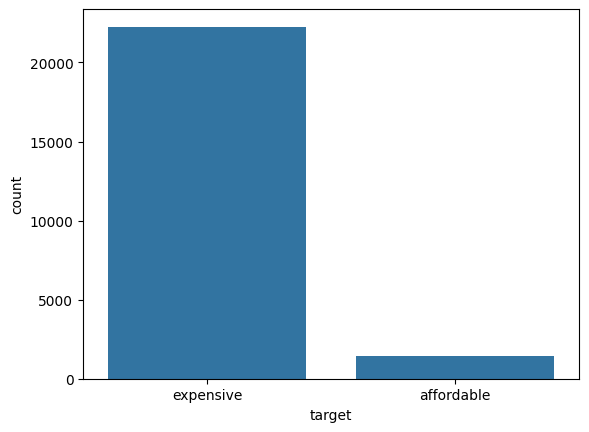

In [ ]:
sns.countplot(x="target", data=cleaned_data)

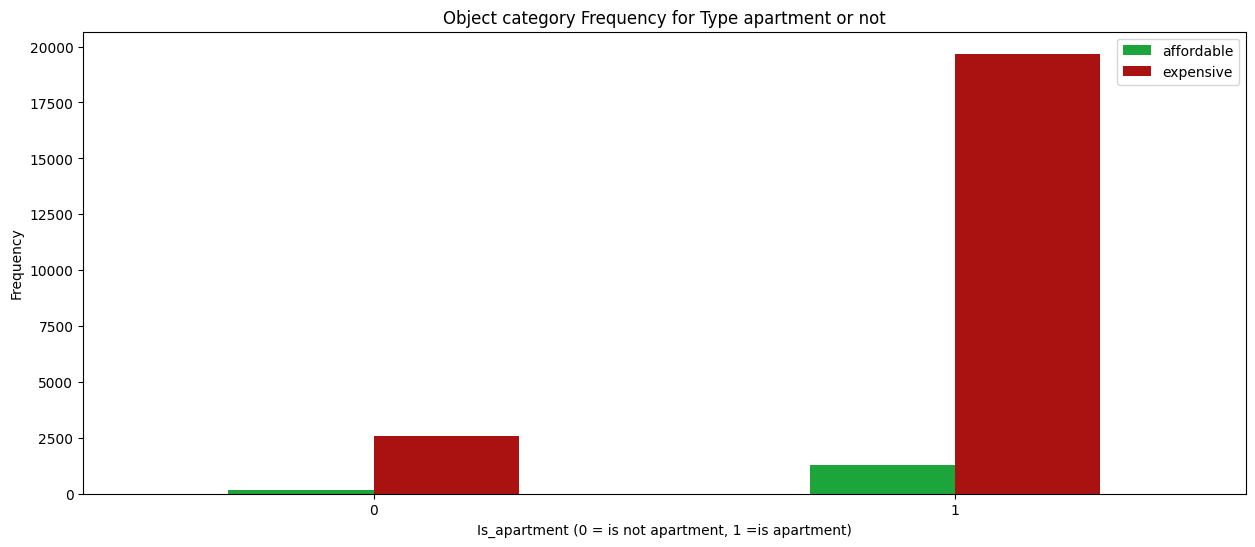

In [ ]:
pd.crosstab(cleaned_data.is_apartment,cleaned_data.target).plot(kind="bar", figsize=(15, 6), color=['#1CA53B', '#AA1111' ])
plt.title('Object category Frequency for Type apartment or not')
plt.xlabel('Is_apartment (0 = is not apartment, 1 =is apartment)')
plt.xticks(rotation=0)
plt.legend(["affordable", "expensive"])
plt.ylabel('Frequency')
plt.show()

In [ ]:
y = cleaned_data['target']
X = cleaneda-data.drop(columns=['target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(random_state=42)

C_grid = [1e-3, 1e-2, 1e-1]
searcher = GridSearchCV(lr, {'C': C_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_lr = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

In [ ]:
svc = SVC(random_state=42)

C_grid = [0.1, 0.25, 0.5, 0.75, 1, 2]
kernel_grid = ["linear", "rbf"]
gamma_grid = ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1, 1]

searcher = GridSearchCV(svc, {'C': C_grid, 'kernel': kernel_grid, 'gamma': gamma_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_svc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

In [ ]:
my_svc = MySVMClassifier()  # собственная реализация

lambda_grid = np.linspace(1e-4, 1e-1, 5)
alpha_grid = np.linspace(1e-4, 1e-1, 5)

searcher = GridSearchCV(my_svc, {'Lambda': lambda_grid, 'alpha': alpha_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_my_svc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

In [ ]:
mlrc = MyLogRegClassifier()  # собственная реализация

lr_grid = [1e-3, 1e-2, 1e-1]
alpha_grid = [1e-3, 1e-2, 1e-1]

searcher = GridSearchCV(mlrc, {'lr': lr_grid, 'alpha': alpha_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_my_lrc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

In [ ]:
knc = KNeighborsClassifier()

n_neighbors_grid = np.arange(1, 20, 2)
weights_grid = ['distance', 'uniform']

searcher = GridSearchCV(knc, {'n_neighbors': n_neighbors_grid, 'weights': weights_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_knc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

In [ ]:
var_smoothing_grid = np.logspace(0, -10, 100)

gnb = GaussianNB()
searcher = GridSearchCV(gnb, {'var_smoothing': var_smoothing_grid}, scoring='accuracy', cv=5)

searcher = searcher.fit(X_train_scaled, y_train)
best_gnb = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

In [ ]:
dtc = DecisionTreeClassifier(random_state=37)

criterion_grid = ["gini", "entropy", "log_loss"]
max_features_grid = [None, 0.5, 2, 5, 10]
min_samples_split_grid = [2, 3, 4, 5, 10]

searcher = GridSearchCV(dtc, {'criterion': criterion_grid, 'max_features': max_features_grid, 'min_samples_split': min_samples_split_grid}, scoring='accuracy', cv=5)

searcher.fit(X_train_scaled, y_train)
best_dtc = searcher.best_estimator_
print("Best params: ", searcher.best_params_)
print("Best score: ", searcher.best_score_)

In [ ]:
y_my_lr = best_my_lrc.predict(X_test_scaled)
y_my_svc = best_my_svc.predict(X_test_scaled)

y_lr = best_lr.predict(X_test_scaled)
y_svc = best_svc.predict(X_test_scaled)
y_knc = best_knc.predict(X_test_scaled)
y_gnb = best_gnb.predict(X_test_scaled)
y_dtc = best_dtc.predict(X_test_scaled)
scores = {
    'LR': accuracy_score(y_test, y_lr),
    'SVM': accuracy_score(y_test, y_svc),
    'KNN': accuracy_score(y_test, y_knc),
    'NB': accuracy_score(y_test, y_gnb),
    'DT': accuracy_score(y_test, y_dtc),
    'MY_LR': accuracy_score(y_test, y_my_lr),
    'MY_SVM': accuracy_score(y_test, y_my_svc)
}

# Create a DataFrame for better visualization
scores_df = pd.DataFrame(list(scores.items()), columns=['Model', 'Accuracy'])

# Plotting the scores using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=scores_df)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)  # Set y-axis limits to show accuracy percentage
plt.show()

In [ ]:
scores_df

In [ ]:

cm_lr = confusion_matrix(y_test, y_lr)
cm_knn = confusion_matrix(y_test, y_knc)
cm_svm = confusion_matrix(y_test, y_svc)
cm_nb = confusion_matrix(y_test, y_gnb)
cm_dtc = confusion_matrix(y_test, y_dtc)
cm_my_lr = confusion_matrix(y_test, y_my_lr)
cm_my_svc = confusion_matrix(y_test, y_my_svc)

In [ ]:
plt.figure(figsize=(15, 15))

plt.suptitle("Confusion Matrices", fontsize=24)
plt.subplots_adjust(wspace = 0.4, hspace= 0.4)

plt.subplot(3,3,1)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,2)
plt.title("K Nearest Neighbors Confusion Matrix")
sns.heatmap(cm_knn,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,3)
plt.title("Support Vector Machine Confusion Matrix")
sns.heatmap(cm_svm,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,4)
plt.title("Naive Bayes Confusion Matrix")
sns.heatmap(cm_nb,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,5)
plt.title("Decision Tree Classifier Confusion Matrix")
sns.heatmap(cm_dtc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,6)
plt.title("My Logistic Regression Confusion Matrix")
sns.heatmap(cm_my_lr,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.subplot(3,3,7)
plt.title("My support Vector Machine Confusion Matrix")
sns.heatmap(cm_my_svc,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})

plt.show()